In [2]:
import gdown
gdown.download('https://bit.ly/3pK7iuu', '../data/ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\til\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:05<00:00, 10.4MB/s]


'../data/ns_book7.csv'

In [4]:
import pandas as pd
ns_book7 = pd.read_csv('../data/ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


- 파이썬에서 그래프를 그리기 위해서는 `matplotlib` 패키지가 필요  

In [ ]:
!pip install matplotlib

In [6]:
# 그래프 함수는 matplotlib.pyplot 모듈 아래에 존재
import matplotlib.pyplot as plt

- **산점도**: 두 변수 혹은 두 특성 값을 직교 좌표계에 점으로 나타내는 그래프  
- `scatter()` 함수: 산점도를 그리는 함수
    - 첫 번째 매개변수에 x축 좌표를, 두 번째 매개변수에 y축 좌표를 전달  
- 그래프를 그리고 난 후에는 `plt.show()`를 호출하여 그래프를 출력 가능  

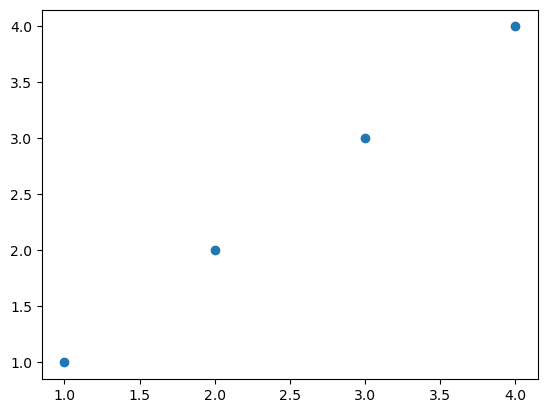

In [7]:
plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()

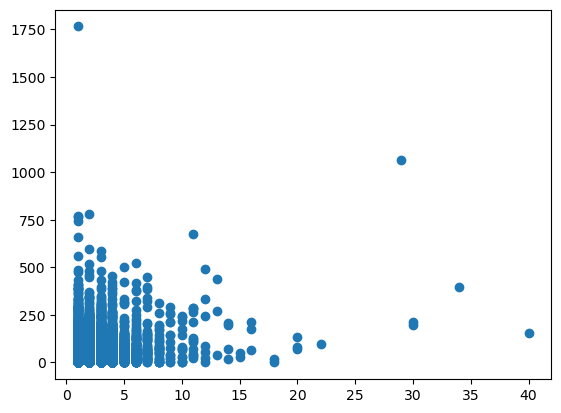

In [8]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'])
plt.show()

- `alpha` 매개변수: 0 ~ 1 사이의 값으로 투명도 지정 가능  
- 데이터가 많이 중첩된 부분은 더 짙게 나타남

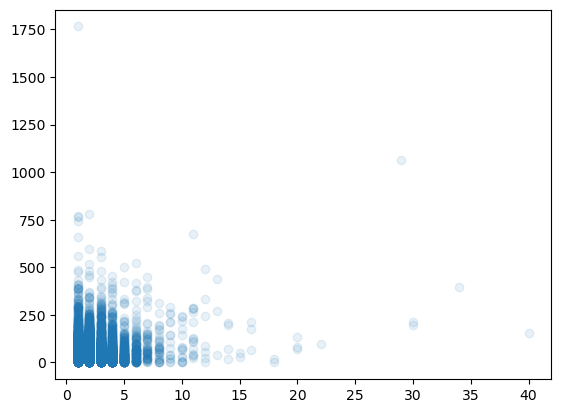

In [9]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

- **히스토그램**: 수치형 특성의 값을 일정한 구간으로 나누어 구간 안에 포함된 데이터 개수를 막대 그래프로 그린 것  
- 도수: 구간 안에 속한 데이터 개수  
- 도수분포표: 히스토그램의 구간과 도수를 표로 요약한 것  

- `hist()` 함수: 히스토그램을 그리는 함수  
- `bins` 매개변수로 몇 개의 구간으로 나눌 지 설정 가능(default: 10)

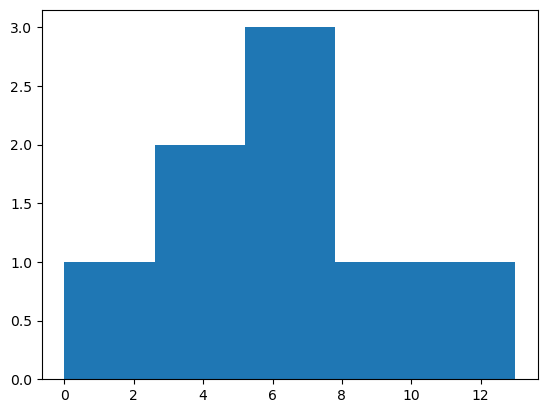

In [10]:
plt.hist([0,3,5,6,7,7,9,13], bins=5)
plt.show()

- 넘파이의 `histogram_bin_edges()` 함수를 통해 히스토그램의 구간을 확인 가능

In [11]:
import numpy as np
np.histogram_bin_edges([0,3,5,6,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

- `randn()` 함수: 원하는 개수만큼의 표준정규분포를 따르는 랜덤한 실수를 생성 후 리스트로 반환
- `seed()` 함수: 언제나 동일한 난수를 추출할 때 사용(유사 난수)

In [13]:
np.random.seed(42)
random_samples = np.random.randn(1000)

In [14]:
# 표준정규분포: 평균이 0이고 표준편차가 1인 정규분포
print(np.mean(random_samples), np.std(random_samples))

0.01933205582232549 0.9787262077473543


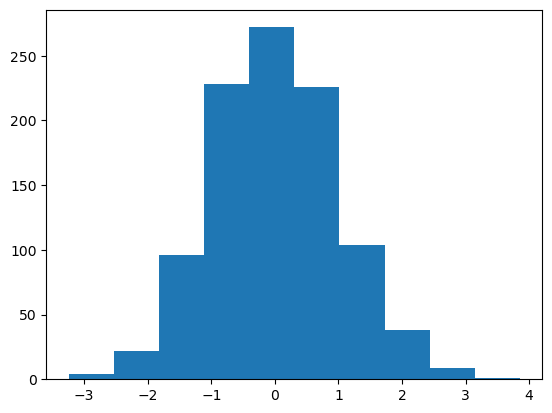

In [15]:
plt.hist(random_samples)
plt.show()

- `yscale()` 함수: y축에 대한 구간 조정이 가능한 함수

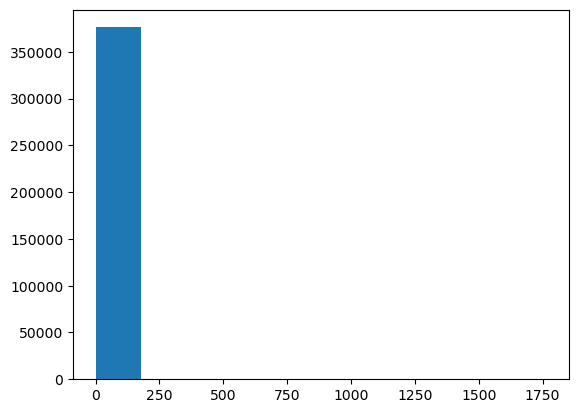

In [16]:
# 구간 조정 전
plt.hist(ns_book7['대출건수'])
plt.show()

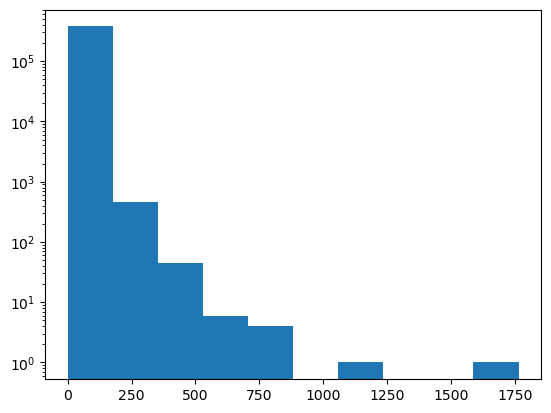

In [17]:
# 구간 조정 후
plt.hist(ns_book7['대출건수'])
plt.yscale('log')
plt.show()

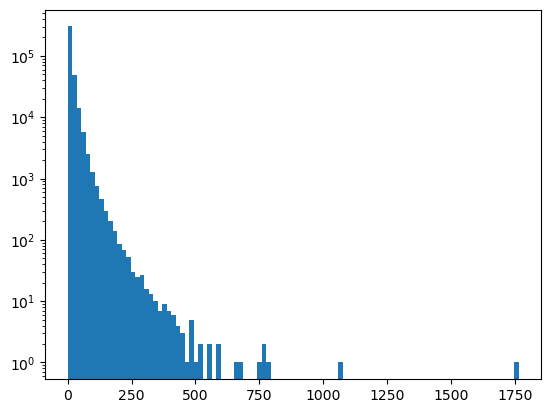

In [18]:
plt.hist(ns_book7['대출건수'], bins=100)
plt.yscale('log')
plt.show()

- `xscale()` 함수: x축에 대한 구간 조정이 가능한 함수

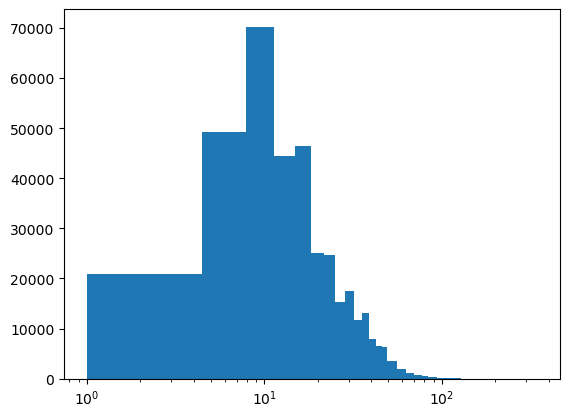

In [19]:
title_len = ns_book7['도서명'].apply(len)
plt.hist(title_len, bins=100)
plt.xscale('log')
plt.show()

- **boxplot**: 최솟값, 사분위수, 최댓값을 사용하여 데이터를 요약한 그래프  
    - 25%와 75% 지점을 밑면과 윗면으로 하는 직사각형 생성 후, 50%에 해당하는 지점에 수평선 생성
    - 사각형의 밑면과 윗면에서 사각형의 높이의 1.5배만큼 떨어진 거리 안에서 가장 멀리 있는 샘플까지 수직선을 그음
- IQR: 제1사분위수(25%)와 제3사분위수(75%) 사이의 거리  
- 이상치: IQR의 1.5배 거리 밖의 데이터  
- `boxplot()` 함수: boxplot을 그리는 함수

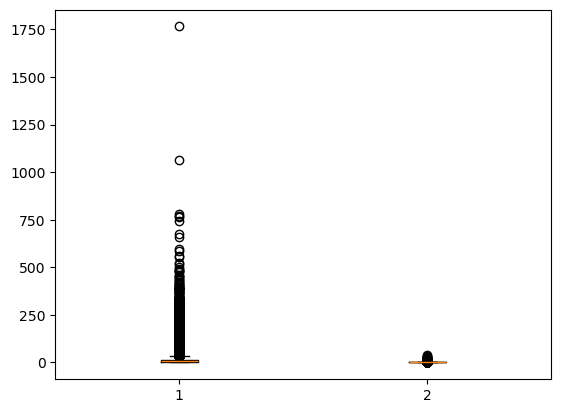

In [21]:
plt.boxplot(ns_book7[['대출건수', '도서권수']])
plt.show()

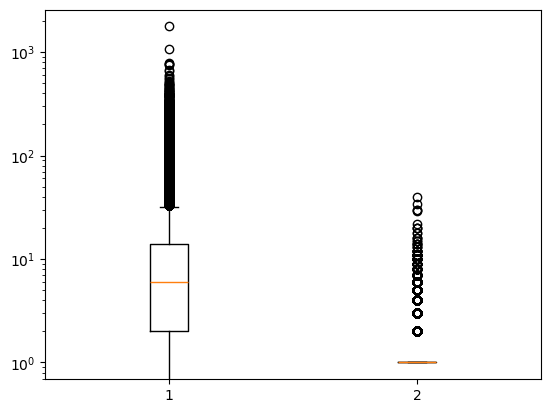

In [22]:
# y축을 로그 스케일로 변경
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')
plt.show()

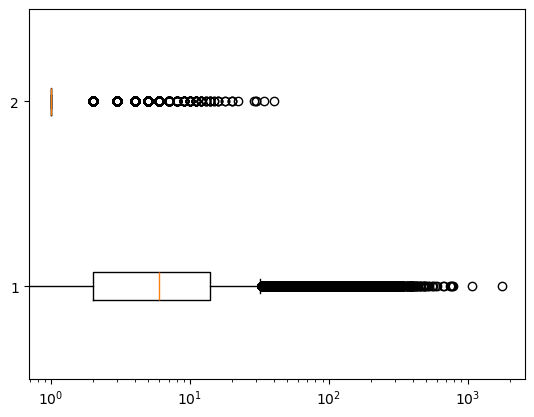

In [ ]:
# vert 매개변수를 True에서 False로 지정하면 수평으로 boxplot을 그릴 수 있음
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log') # 축이 변했으므로 로그 스케일도 x축에 지정   
plt.show()

- `whis` 매개변수: 수염의 길이를 조정하는 매개변수  
- `whis`는 백분율로도 지정 가능

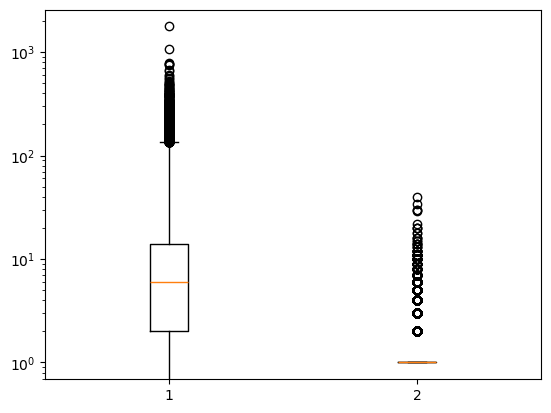

In [24]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)
plt.yscale('log')
plt.show()

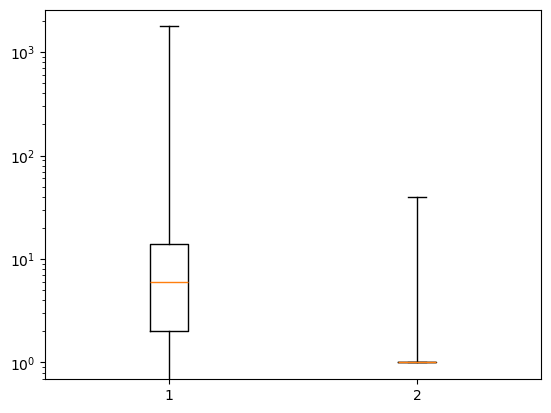

In [25]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=(0,100))
plt.yscale('log')
plt.show()

- 판다스에서도 그래프를 그릴 수 있는 여러 메서드를 제공

c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

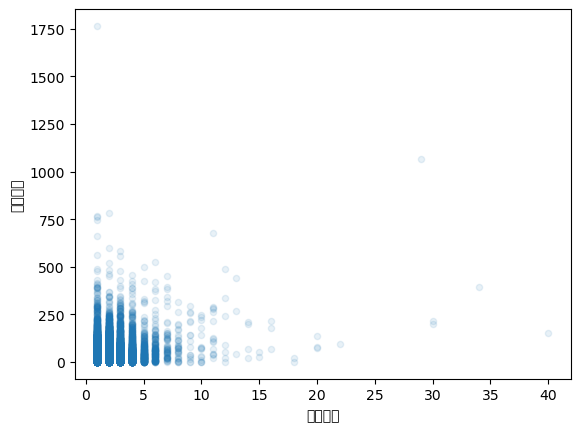

In [26]:
# 산점도 그리기
ns_book7.plot.scatter('도서권수', '대출건수', alpha=0.1)
plt.show()

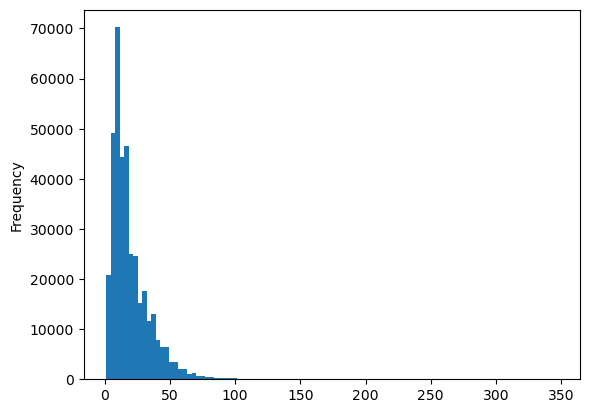

In [27]:
# 히스토그램 그리기
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

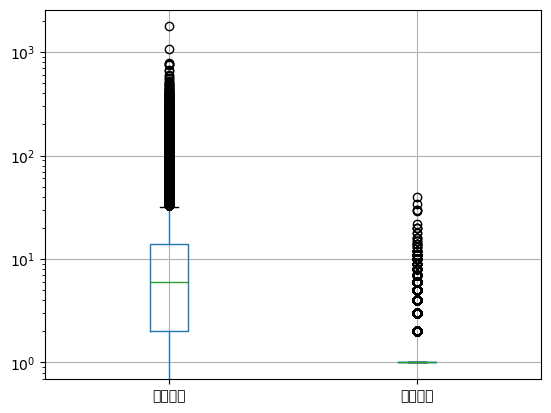

In [28]:
# boxplot 그리기
ns_book7[['대출건수','도서권수']].boxplot()
plt.yscale('log')
plt.show()